# Career Intelligence & Salary Prediction Platform

## Introduction

In today's competitive job market, understanding the factors that influence employee compensation is essential for job seekers, employers, and business decision-makers. Salary levels are affected by a combination of factors such as professional experience, educational qualifications, industry, company size, certifications, work location, and remote work opportunities. Analysing these factors can provide valuable insights into workforce trends and help individuals make informed career decisions.

This project aims to develop a Career Intelligence and Salary Prediction Platform using data analytics and machine learning techniques. The dataset contains 250,000 employee records across various industries, job roles, education levels, and locations. Through exploratory data analysis, the project investigates key drivers of salary differences and identifies patterns that influence compensation outcomes.

In addition to descriptive analytics, predictive modelling techniques are applied to estimate salaries based on employee characteristics. The project also demonstrates the end-to-end data analytics workflow, including data quality assessment, data cleaning, exploratory analysis, feature engineering, machine learning model development, and business intelligence reporting.

The primary objectives of this project are:

* Analyse salary distributions across different job roles and industries.
* Evaluate the impact of experience, education, certifications, and remote work on employee compensation.
* Identify the highest-paying industries, job categories, and career pathways.
* Develop machine learning models capable of predicting salaries based on workforce characteristics.
* Generate business insights and recommendations to support career planning and workforce strategy.

The findings from this analysis can help professionals understand market trends, identify factors associated with higher earnings, and make data-driven career decisions. From a business perspective, the project demonstrates how analytics can be used to understand compensation patterns and support strategic workforce planning.


In [2]:
# Data Loading and Initial Inspection.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('job_salary_prediction_dataset.csv')
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [3]:
print("Rows: ", df.shape[0])
print("Columns: ", df.shape[1])

Rows:  250000
Columns:  10


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [5]:
df.isnull().sum()

,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


In [6]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [7]:
print("Duplicated Rows: ",df.duplicated().sum())

Duplicated Rows:  0


## Data Quality Findings

The dataset contains 250,000 records and 10 variables representing employee characteristics and compensation information. Data quality assessment revealed no missing values and no duplicate records, indicating a high-quality dataset suitable for further analysis.

The dataset consists of both numerical and categorical variables, providing a balanced foundation for exploratory analysis and predictive modelling. Numerical features include experience years, skills count, certifications, and salary, while categorical variables capture job title, education level, industry, company size, location, and remote work status.

Summary statistics indicate an average salary of 145,718 and a median salary of 143,453. The relatively small difference between these values suggests that salary distribution may be reasonably balanced with limited extreme skewness. Overall, the dataset is well-structured and requires minimal preprocessing before analysis.


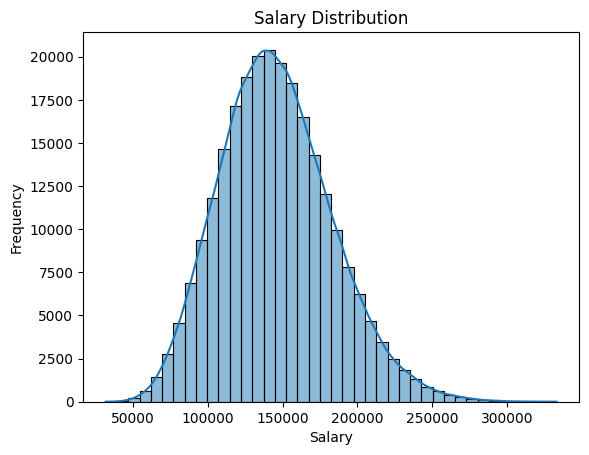

In [8]:
sns.histplot(df['salary'],bins=40, kde=True)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

### Salary Distribution Analysis

The salary distribution follows an approximately normal bell-shaped pattern, with most employees earning between 100,000 and 190,000 annually. The highest concentration of salaries occurs around 140,000 to 150,000, which closely aligns with the dataset's average salary of 145,718.

The distribution exhibits a slight positive skew, with a smaller number of employees earning significantly higher salaries above 250,000. This suggests that while high-paying positions exist, they represent a relatively small proportion of the workforce.

Overall, the salary distribution indicates a balanced workforce compensation structure with most employees concentrated around the middle-income range and limited extreme outliers.


In [9]:
top_jobs= df.groupby('job_title')['salary'].mean().sort_values(ascending=False).head(10)
top_jobs

,salary
job_title,
AI Engineer,173498.480640
Machine Learning Engineer,163022.504570
Product Manager,157594.932029
Cloud Engineer,152102.535290
DevOps Engineer,149959.266791
Cybersecurity Analyst,148697.695548
Data Scientist,147258.214409
Software Engineer,141739.521460
Backend Developer,139202.768663


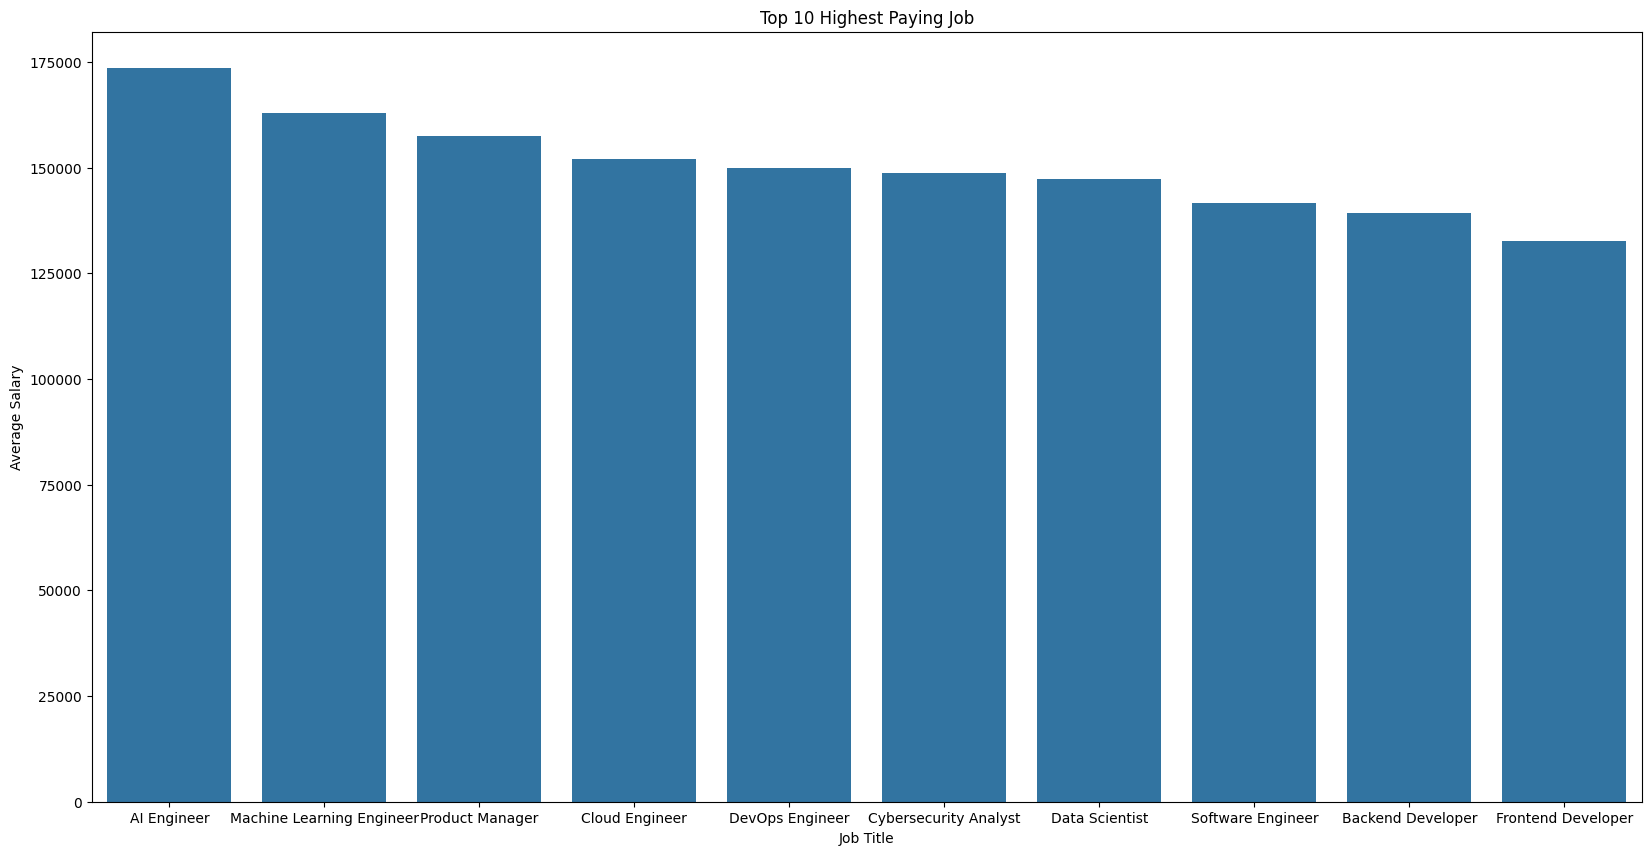

In [10]:
plt.figure(figsize=(20,10))

sns.barplot(x=top_jobs.index, y=top_jobs.values)
plt.title("Top 10 Highest Paying Job")
plt.xlabel("Job Title")
plt.ylabel("Average Salary")
plt.show()

### Top Paying Job Titles Analysis

The analysis reveals that AI Engineer is the highest-paying role in the dataset, with an average annual salary of approximately $173,500. This is followed by Machine Learning Engineer and Product Manager positions, both of which command significantly higher salaries than the overall dataset average.

The strong representation of AI, Machine Learning, Cloud, and DevOps roles among the highest-paying positions reflects the increasing demand for advanced technical skills and digital transformation initiatives across industries. These positions typically require specialized expertise, making them more valuable in the labour market.

Data Scientist roles also appear within the top ten highest-paying occupations, indicating strong earning potential for professionals with analytical, statistical, and machine learning capabilities.

From a career planning perspective, professionals seeking higher compensation may benefit from developing skills in artificial intelligence, machine learning, cloud computing, cybersecurity, and data science, as these areas demonstrate the strongest salary outcomes within the dataset.


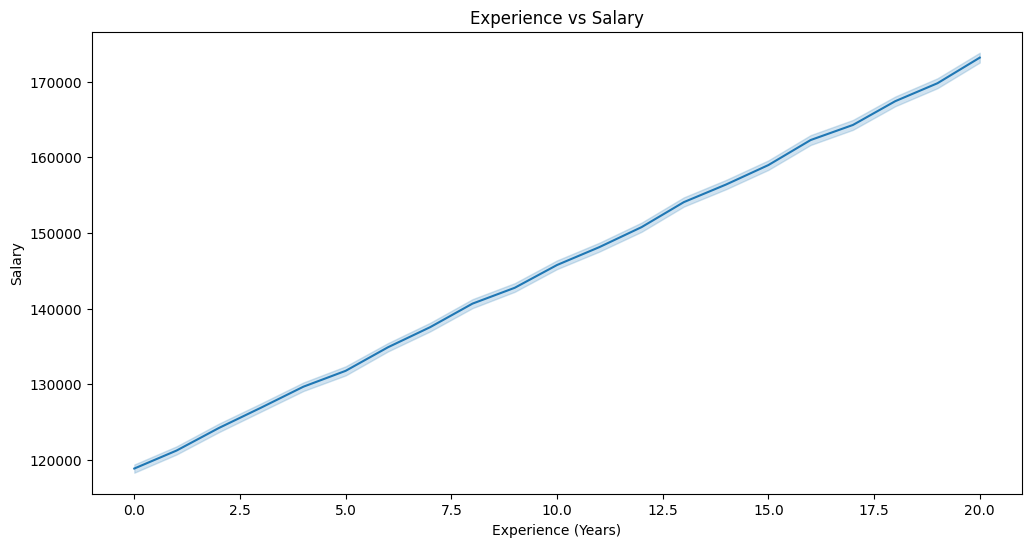

In [11]:
plt.figure(figsize=(12,6))

sns.lineplot(data=df, x='experience_years', y='salary')
plt.title("Experience vs Salary")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.show()

In [12]:
experience_salary = (
    df.groupby('experience_years')['salary']
      .mean()
)

print(experience_salary)

experience_years
0     118872.622755
1     121250.527183
2     124228.943849
3     126921.603112
4     129688.783435
5     131787.250717
6     134898.296712
7     137560.810366
8     140667.762731
9     142763.834683
10    145771.972998
11    148133.173236
12    150779.033238
13    154082.616121
14    156413.152885
15    158981.141636
16    162290.866980
17    164282.181423
18    167421.185837
19    169797.362442
20    173179.709650
Name: salary, dtype: float64


### Experience and Salary Analysis

The analysis demonstrates a strong positive relationship between professional experience and salary. Average compensation increases consistently as employees gain additional years of experience, indicating that experience is a significant driver of earning potential.

Employees with no professional experience earn an average salary of approximately 118,873, while employees with 20 years of experience earn approximately 173,180. This represents an overall increase of more than 54,000 across a 20-year career span.

The relationship appears almost linear, suggesting that each additional year of experience contributes positively to salary growth. This finding aligns with labour market expectations, where experienced professionals are rewarded for accumulated knowledge, expertise, and leadership capabilities.

From a career development perspective, the results highlight the long-term financial value of professional experience and continuous career progression.



In [13]:
education_salary = (
    df.groupby('education_level')['salary']
      .mean()
      .sort_values(ascending=False)
)

print(education_salary)

education_level
PhD            163976.005295
Master         153305.307833
Bachelor       142410.531291
Diploma        137158.574976
High School    131715.336243
Name: salary, dtype: float64


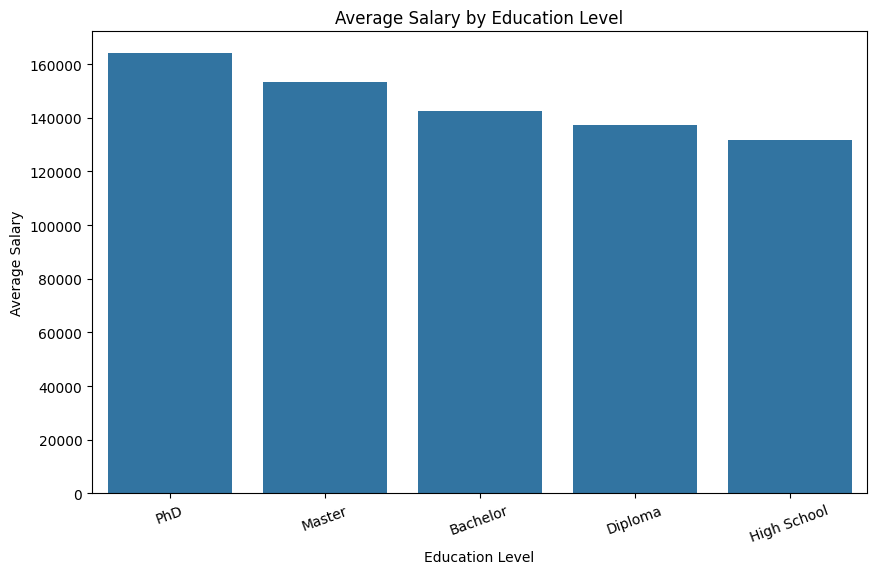

In [14]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=education_salary.index,
    y=education_salary.values
)

plt.title('Average Salary by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Salary')


plt.xticks(rotation=20)
plt.show()

### Education Level and Salary Analysis

The analysis indicates a strong positive relationship between educational attainment and salary levels. Employees with higher qualifications consistently earn higher average salaries across the dataset.

PhD holders receive the highest average salary at approximately 163,976 per year, followed by Master's degree holders at 153,305. Bachelor's degree holders earn an average salary of 142,411, while employees with Diploma and High School qualifications earn lower average salaries.

The results suggest that advanced education provides a measurable financial advantage in the labour market. Employees with a PhD earn approximately 32,000 more annually than individuals whose highest qualification is High School. Similarly, Master's degree holders earn over 21,000 more than High School graduates on average.

These findings highlight the economic value of higher education and suggest that investment in advanced qualifications may contribute to increased earning potential over the course of a professional career.


In [15]:
remote_salary = df.groupby('remote_work')['salary'].mean().sort_values(ascending=False)
remote_salary

,salary
remote_work,
Yes,149279.589822
Hybrid,143969.899839
No,143932.300941


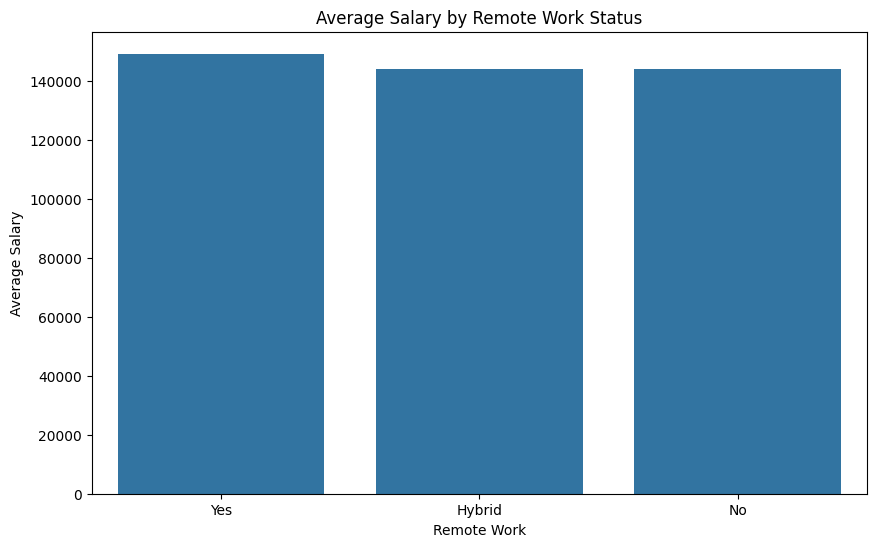

In [16]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=remote_salary.index,
    y=remote_salary.values
)

plt.title('Average Salary by Remote Work Status')
plt.xlabel('Remote Work')
plt.ylabel('Average Salary')
plt.show()

### Remote Work and Salary Analysis

The analysis suggests that remote work opportunities are associated with higher average salaries compared to both hybrid and fully on-site roles. Employees working remotely earn an average salary of approximately 149,280 per year, while hybrid and on-site employees earn approximately 143,970 and 143,932 respectively.

Although the difference is not extremely large, remote positions demonstrate a salary premium of more than 5,000 annually compared to other working arrangements. This may reflect increased demand for specialized talent in remote-friendly industries, broader access to national or international labour markets, and competition for highly skilled professionals.

Interestingly, hybrid and on-site roles exhibit nearly identical average salaries, suggesting that the primary distinction exists between fully remote and non-remote employment arrangements.

From a workforce planning perspective, the findings indicate that remote work may provide a modest financial advantage while also offering additional flexibility benefits for employees.


In [17]:
cert_salary = (
    df.groupby('certifications')['salary']
      .mean()
)

cert_salary

,salary
certifications,
0,141492.411877
1,143428.188796
2,144868.706976
3,146884.292491
4,148103.275327
5,149607.379081


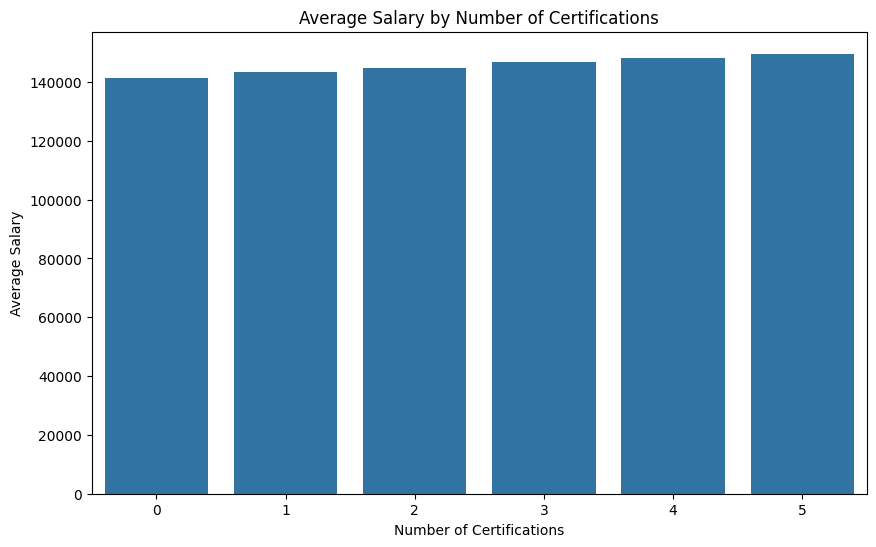

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=cert_salary.index,
    y=cert_salary.values
)

plt.title('Average Salary by Number of Certifications')
plt.xlabel('Number of Certifications')
plt.ylabel('Average Salary')
plt.show()

### Certifications and Salary Analysis

The analysis reveals a positive relationship between professional certifications and salary levels. As the number of certifications increases, average salary also increases steadily across the workforce.

Employees with no certifications earn an average salary of approximately 141,492, while employees holding five certifications earn approximately 149,607. This represents an increase of more than 8,000 annually.

Although certifications appear to contribute positively to compensation, the magnitude of their impact is smaller than that observed for education level and professional experience. This suggests that certifications may enhance earning potential by complementing existing qualifications and experience rather than serving as the primary driver of salary growth.

From a career development perspective, certifications can provide incremental salary benefits and may strengthen professional competitiveness in the labour market. However, long-term salary growth appears to be more strongly associated with accumulated experience and higher educational attainment.


In [19]:
industry_salary = (
    df.groupby('industry')['salary']
      .mean()
      .sort_values(ascending=False)
)

industry_salary

,salary
industry,
Education,145993.564547
Media,145891.271071
Telecom,145876.511967
Technology,145863.808377
Finance,145801.639468
Healthcare,145759.995702
Government,145613.869242
Manufacturing,145530.603301
Consulting,145451.638293


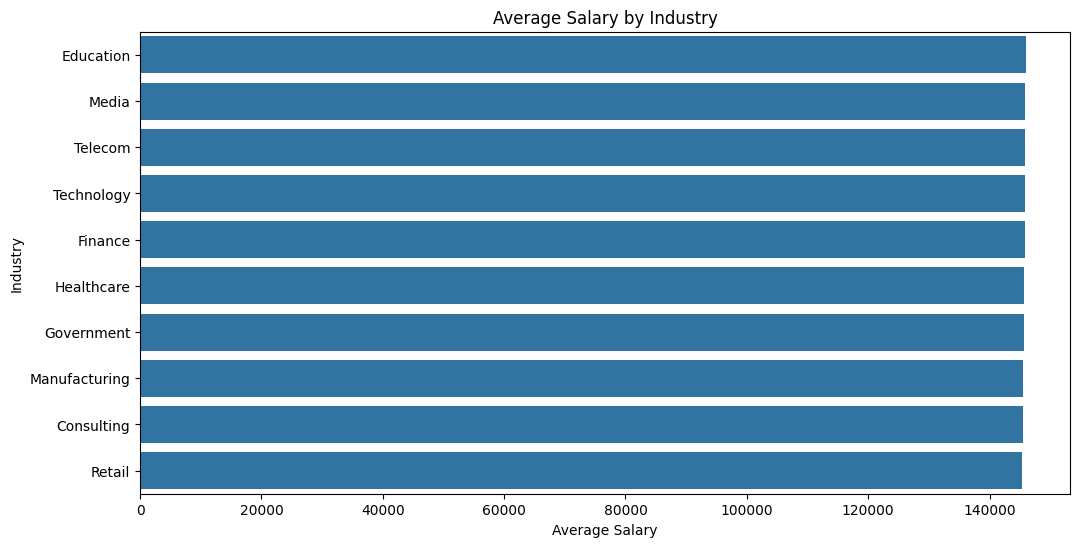

In [20]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=industry_salary.values,
    y=industry_salary.index
)

plt.title('Average Salary by Industry')
plt.xlabel('Average Salary')
plt.ylabel('Industry')

plt.show()

### Industry and Salary Analysis

The analysis reveals minimal variation in average salaries across industries. While the Education industry reports the highest average salary at approximately 145,994 and Retail reports the lowest at approximately 145,400, the difference between the highest and lowest industry averages is less than 600 annually.

This finding suggests that industry membership alone has limited influence on salary outcomes within this dataset. Compared to factors such as professional experience, education level, and job title, industry appears to be a relatively weak predictor of compensation.

The results indicate that individual characteristics and role-specific factors may play a more significant role in determining salary than the industry in which an employee works. Consequently, industry is unlikely to be one of the strongest drivers in the salary prediction model.


In [21]:
company_salary = (
    df.groupby('company_size')['salary']
      .mean()
      .sort_values(ascending=False)
)

company_salary

,salary
company_size,
Enterprise,169616.398957
Large,155711.112489
Medium,141537.535991
Small,134356.864298
Startup,127289.011974


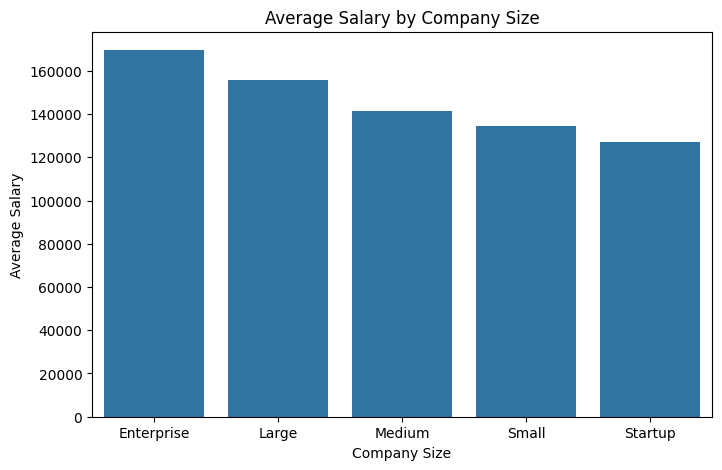

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=company_salary.index,
    y=company_salary.values
)

plt.title('Average Salary by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Average Salary')

plt.show()

### Company Size and Salary Analysis

The analysis reveals a strong positive relationship between company size and employee compensation. Enterprise organizations offer the highest average salary at approximately 169,616 per year, while Startup companies offer the lowest average salary at approximately 127,289.

The salary difference between Enterprise and Startup organizations exceeds 42,000 annually, making company size one of the strongest predictors of compensation identified within the dataset. Large organizations also demonstrate significantly higher salary levels compared to Medium and Small companies.

This pattern may reflect the greater financial resources, larger budgets, and more complex operational requirements typically associated with larger organizations. Enterprise companies may also compete more aggressively for experienced and highly skilled professionals.

The findings suggest that company size plays a substantial role in salary determination and should be considered an important factor in both career planning and salary prediction modelling.


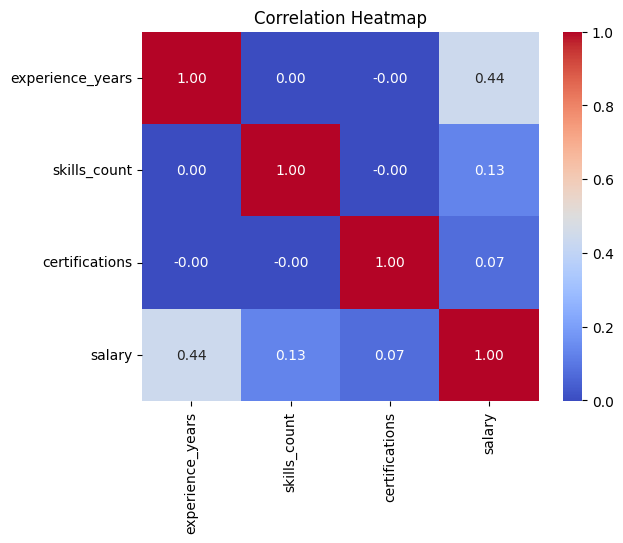

In [23]:
numeric_df = df.select_dtypes(include = ['int64','float64'])

corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Correlation Analysis

A correlation matrix was used to examine the strength of relationships between numerical variables within the dataset. The analysis indicates that professional experience has the strongest relationship with salary, with a correlation coefficient of 0.44. This suggests a moderate positive association, where employees with greater experience tend to earn higher salaries.

Skills count and certifications exhibit positive but relatively weak correlations with salary, with coefficients of 0.13 and 0.07 respectively. While these variables appear to contribute to compensation, their influence is substantially smaller than that of professional experience.

The analysis also shows negligible relationships between experience, skills count, and certifications, indicating that these variables operate largely independently within the dataset.

Overall, the correlation analysis supports earlier findings from the exploratory analysis, confirming that professional experience is one of the most influential numerical predictors of salary and is likely to play an important role in predictive modelling.


## Phase 2: Machine Learning

In [24]:
X = df.drop('salary', axis=1)
y = df['salary']

print(X.shape)
print(y.shape)

(250000, 9)
(250000,)


In [25]:
X.dtypes

,0
job_title,object
experience_years,int64
education_level,object
skills_count,int64
industry,object
company_size,object
location,object
remote_work,object
certifications,int64


In [26]:
X_encoded = pd.get_dummies(X, drop_first=True)
X_encoded.head()

,experience_years,skills_count,certifications,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,job_title_DevOps Engineer,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,10,2,2,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,5,17,0,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
2,18,4,1,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,19,13,0,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,15,7,0,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True


In [27]:
print("Original Shape: ", X.shape)
print("Encoded Shape: ", X_encoded.shape)

Original Shape:  (250000, 9)
Encoded Shape:  (250000, 42)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42)

print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)

X_train shape:  (200000, 42)
X_test shape:  (50000, 42)


In [29]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [30]:
y_pred_lr = lr.predict(X_test)

In [31]:
from sklearn.metrics import(mean_absolute_error, r2_score)

mae = mean_absolute_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print("MAE: ", mae)
print("R2: ", r2)


MAE:  5436.0969367518055
R2:  0.963469022844696


### Linear Regression Model Performance

A Linear Regression model was trained to predict employee salaries using workforce characteristics such as job title, experience, education level, skills count, industry, company size, location, remote work status, and certifications.

The model achieved a Mean Absolute Error (MAE) of approximately 5,436, indicating that salary predictions were, on average, within 5,436 of the actual salary values. Given the wide salary range present in the dataset, this represents a relatively low prediction error.

The model also achieved an R² score of 0.963, meaning that approximately 96.3% of the variation in salary can be explained by the features included in the model. This suggests a strong relationship between employee characteristics and compensation outcomes within the dataset.

Overall, the results indicate that the selected features provide substantial predictive power and are effective for estimating salary levels.


In [32]:
coefficients = pd.DataFrame({'Feature' : X_encoded.columns, 'Coefficient': lr.coef_})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

coefficients.head(20)

,Feature,Coefficient
39,location_USA,41971.549495
31,location_Canada,27941.449186
17,education_level_PhD,21532.269290
38,location_UK,20967.211802
32,location_Germany,13988.379511
16,education_level_Master,10829.817459
41,remote_work_Yes,5338.885135
0,experience_years,2698.565043
2,certifications,1613.176976
1,skills_count,857.188031


In [33]:
coefficients[
    coefficients['Feature'].str.contains('company_size')
].sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
27,company_size_Large,-14124.660414
28,company_size_Medium,-28281.013207
29,company_size_Small,-35406.943077
30,company_size_Startup,-42399.305090


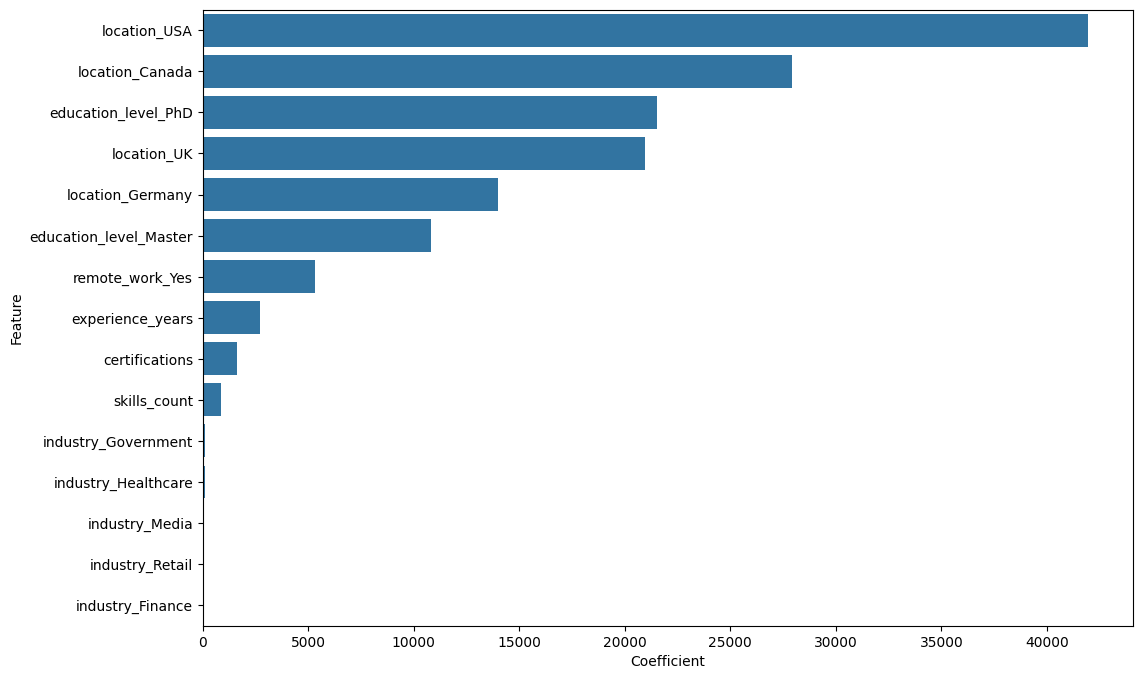

In [34]:
top_coef = coefficients.copy()
top_coef = top_coef.sort_values(by='Coefficient', ascending=False).head(15)
plt.figure(figsize=(12,8))
sns.barplot(x='Coefficient', y='Feature', data=top_coef)
plt.show()

In [35]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators = 100, random_state = 42, n_jobs = -1)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [36]:
from sklearn.metrics import(mean_absolute_error, r2_score)

mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

print("MAE: ", mae)
print("R2: ", r2)

MAE:  5693.018592038335
R2:  0.9608581821826041


Two machine learning models were evaluated for salary prediction. Linear Regression achieved a lower MAE (5,436) and a higher R² score (0.963) than Random Forest Regression. The results suggest that salary relationships within the dataset are predominantly linear, allowing Linear Regression to model compensation patterns more effectively than the more complex Random Forest approach.

In [37]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [5436.10, 5693.02],
    'R2': [0.9635, 0.9609]
})

comparison

,Model,MAE,R2
0,Linear Regression,5436.10,0.9635
1,Random Forest,5693.02,0.9609


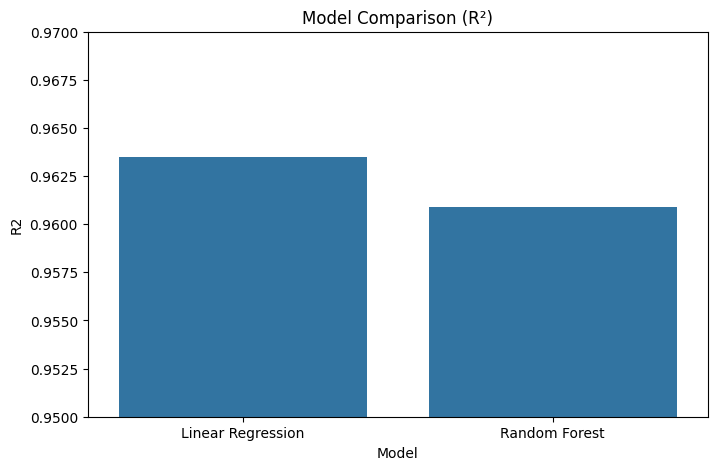

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x='Model',
    y='R2'
)

plt.title('Model Comparison (R²)')
plt.ylim(0.95, 0.97)

plt.show()

In [39]:
new_employee = pd.DataFrame({
    'job_title': ['Data Scientist'],
    'experience_years': [8],
    'education_level': ['Master'],
    'skills_count': [12],
    'industry': ['Technology'],
    'company_size': ['Enterprise'],
    'location': ['USA'],
    'remote_work': ['Yes'],
    'certifications': [3]
})

new_employee_encoded = pd.get_dummies(new_employee)

new_employee_encoded = new_employee_encoded.reindex(
    columns=X_encoded.columns,
    fill_value=0
)

predicted_salary = lr.predict(new_employee_encoded)

print(f"Predicted Salary: ${predicted_salary[0]:,.0f}")

Predicted Salary: $214,767
